### Spherical transform

The goal of this notebook is to implement a working method that allow for spherical transforms. The rationale behind is that we inverting for the core flow using the _real_ SV, we are lacking constraints in the physical domain, to tell the network how to balance the power between the small-scales part of the magnetic field, and the core flow. However, we have access to statistics on Gauss coefficients (e.g. their spectrum) in the spectral domain. Thus, it is appealing to try to add another constraint on the field's spectrum. To do so, the transformation between the physical domain and the spectral domain is done through __spherical transform__.

As we are not interested into very large truncation degrees, we can rely on methods already implemented inside the `scipy` package to generate the associated Legendre polynomials. For all matrices and tensors operations, we rely on the `numpy` method called `einsum`.

We have $P_{n,m}(\mu)$ the unormalized associated Legendre polynomials, with $\mu = \cos(\theta)$. We define the Schmidt quasi-normalised counterpart as

$$ P_n^m = \sqrt{\frac{(2 - \delta_{m,0}) (n - m)!}{(n + m)!}} P_{n,m} $$

with $\delta$ the Kronecker delta function. For clarity, the phase factor $(-1)^m$ is not integrated in the definition of the polynomials. From this, we define the real, surfacic spherical harmonics as $C_n^m = P_n^m (\mu) \cos(m\phi)$ and $S_n^m = P_n^m (\mu) \sin(m\phi)$.

Then, the Gauss coefficients read

$$ a_n^m = \frac{2n + 1}{4\pi} \oiint_\Omega d\Omega f(\theta,\phi) C_n^m (\cos \theta) $$
$$ b_n^m = \frac{2n + 1}{4\pi} \oiint_\Omega d\Omega f(\theta,\phi) S_n^m (\cos \theta) $$

with $d\Omega = \sin(\theta) d\theta d\phi$ the surface element.

In [1]:
import scipy
import numpy
import pygeotools

In [2]:
pygeo = pygeotools.pygeotools()

pygeotools was initialized with `verbose=True`.


In [3]:
# Loading the data
pygeo.loadModel("100path", "pygeodyn_hdf5", "../geodynamo.hdf5")

In [4]:
l_trunc = 30

# Defining the context
context = {"lmax": l_trunc, "r": pygeo.constants["rCore"]}

# Defining the grid size (3°)
grid_size = 3

# Defining the grid
if not pygeo.isGrid(f"{grid_size}deg"):
    pygeo.addGrid(f"{grid_size}deg", grid_size, grid_size)

# Setting the grid
pygeo.setGrid(f"{grid_size}deg")

# Retrieving the grid
_, (thetas, phis) = pygeo.getCurrentGrid()

In [5]:
# Method for computing the spherical harmonics
def spherical_harmonics(lmax, thetas, phis):

    # Defining the degrees and modes
    l = numpy.arange(0, lmax + 1, 1)
    m = l[::]

    # Creating the meshing
    θ, φ = numpy.meshgrid(thetas, phis, indexing="ij")
    L, M = numpy.meshgrid(l, m, indexing="ij")

    # Computing the unormalized associated Legendre polynomials
    # (restricting to m >= 0)
    z = numpy.cos(θ)
    p, *_ = scipy.special.assoc_legendre_p_all(lmax, lmax, z, branch_cut=2, diff_n=0)
    p = p[:, :(lmax + 1), ...]

    def dirac(x):
        return numpy.float64(x == 0)
    
    def fact(x):
        return numpy.float64(scipy.special.factorial(x, exact=False, extend="zero"))

    # Computing Schmidt quasi-normalisation
    schmidt_norm = numpy.sqrt((2 - dirac(M)) * fact(L - M) / fact(L + M))

    # Adding the norm
    p = numpy.einsum('ij,ijkl->ijkl', schmidt_norm, p, optimize=True)

    # Defining cos(mφ) and sin(mφ)
    mφ = numpy.einsum('ij,kl->ijkl', M, φ, optimize=True)
    cos_mφ = numpy.cos(mφ)
    sin_mφ = numpy.sin(mφ)

    # Defining the real spherical harmonics
    y_cos = cos_mφ * p
    y_sin = sin_mφ * p

    return y_cos, y_sin

y_cos, y_sin = spherical_harmonics(l_trunc, thetas, phis)

#### Testing the normalisation using _naive_ integration

In [6]:
# Testing the normalisation
θ, φ = numpy.meshgrid(thetas, phis, indexing="ij")
sinθ = numpy.sin(θ)

dθ = numpy.gradient(thetas).mean()
dφ = numpy.gradient(phis).mean()

dΩ = sinθ * dθ * dφ

l1 = 3
m1 = 3
l2 = 3
m2 = 3

I = numpy.einsum('ij,ij,ij', y_cos[l1, m1], y_cos[l2, m2], dΩ, optimize=True)
I_theo = 4 * numpy.pi / (2 * l1 + 1)

print(I, I_theo)

1.82511458441278 1.7951958020513104


#### Testing on a _real_ field

Text(0.5, 1.0, 'Reconstructed $u_\\theta$')

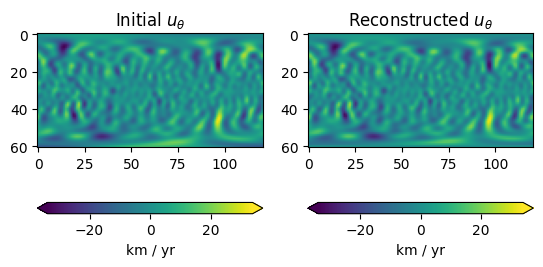

In [7]:
# Defining the degrees and modes
l = numpy.arange(0, l_trunc + 1, 1)
m = l[::]

# Creating the meshing
L, M = numpy.meshgrid(l, m, indexing="ij")

# Computing the field
U = pygeo.addMeasure("100path", "U", context)

# Retrieving azimuthal and polar components
uθ = U[0,...,1]
uφ = U[0,...,2]

# Constant stemming from Schmidt quasi-normalisation
C = (2 * L + 1) / (4 * numpy.pi)

# Decomposing the field
coeffs_cos = numpy.einsum('ijkl,ij,kl,kl->ij', y_cos, C, uθ, dΩ, optimize=True)
coeffs_sin = numpy.einsum('ijkl,ij,kl,kl->ij', y_sin, C, uθ, dΩ, optimize=True)

uθ_reconstructed = numpy.einsum('ij,ijkl->kl', coeffs_cos, y_cos, optimize=True) + \
    numpy.einsum('ij,ijkl->kl', coeffs_sin, y_sin, optimize=True)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2)

vmax = numpy.abs(uθ).max()

im1 = axes[0].imshow(uθ, vmin=-vmax, vmax=vmax)
im2 = axes[1].imshow(uθ_reconstructed, vmin=-vmax, vmax=vmax)

cb1 = plt.colorbar(im1, orientation="horizontal", extend="both")
cb2 = plt.colorbar(im2, orientation="horizontal", extend="both")

cb1.set_label("km / yr")
cb2.set_label("km / yr")

axes[0].set_title("Initial $u_\\theta$")
axes[1].set_title("Reconstructed $u_\\theta$")

#### Application on the toroidal and poloidal fields

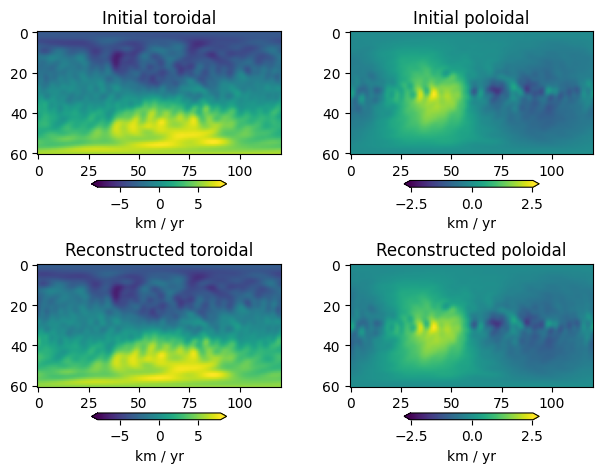

In [8]:
# Retrieving the coefficients
coeffs = pygeo.getQuantity("100path", "U")

kmax = coeffs.shape[-1] // 2

tnm = coeffs[0,:kmax]
snm = coeffs[0,kmax:]

# Formatting the coefficients
coeffs_t_cos = numpy.zeros((l_trunc + 1, l_trunc + 1))
coeffs_t_sin = numpy.zeros((l_trunc + 1, l_trunc + 1))
coeffs_s_cos = numpy.zeros((l_trunc + 1, l_trunc + 1))
coeffs_s_sin = numpy.zeros((l_trunc + 1, l_trunc + 1))

k = 0

for l in range(1, l_trunc + 1):
    for m in range(0, l + 1):
        coeffs_t_cos[l, m] = tnm[k]
        coeffs_s_cos[l, m] = snm[k]
        k += 1

        if m != 0:
            coeffs_t_sin[l, m] = tnm[k]
            coeffs_s_sin[l, m] = snm[k]
            k += 1

# Reconstructing
toroidal_field = numpy.einsum('ij,ijkl->kl', coeffs_t_cos, y_cos, optimize=True) + \
    numpy.einsum('ij,ijkl->kl', coeffs_t_sin, y_sin, optimize=True)
poloidal_field = numpy.einsum('ij,ijkl->kl', coeffs_s_cos, y_cos, optimize=True) + \
    numpy.einsum('ij,ijkl->kl', coeffs_s_sin, y_sin, optimize=True)

# Decomposing
coeffs_t_cos_2 = numpy.einsum('ijkl,ij,kl,kl->ij', y_cos, C, toroidal_field, dΩ, optimize=True)
coeffs_t_sin_2 = numpy.einsum('ijkl,ij,kl,kl->ij', y_sin, C, toroidal_field, dΩ, optimize=True)
coeffs_s_cos_2 = numpy.einsum('ijkl,ij,kl,kl->ij', y_cos, C, poloidal_field, dΩ, optimize=True)
coeffs_s_sin_2 = numpy.einsum('ijkl,ij,kl,kl->ij', y_sin, C, poloidal_field, dΩ, optimize=True)

# Reconstruction after decomposition
toroidal_field_reconstructed = numpy.einsum('ij,ijkl->kl', coeffs_t_cos_2, y_cos, optimize=True) + \
    numpy.einsum('ij,ijkl->kl', coeffs_t_sin_2, y_sin, optimize=True)
poloidal_field_reconstructed = numpy.einsum('ij,ijkl->kl', coeffs_s_cos_2, y_cos, optimize=True) + \
    numpy.einsum('ij,ijkl->kl', coeffs_s_sin_2, y_sin, optimize=True)

# Comparing
fig, axes = plt.subplots(2, 2)

vmax_tor = numpy.abs(toroidal_field).max()
vmax_pol = numpy.abs(poloidal_field).max()

im1 = axes[0,0].imshow(toroidal_field, vmin=-vmax_tor, vmax=vmax_tor)
im2 = axes[1,0].imshow(toroidal_field_reconstructed, vmin=-vmax_tor, vmax=vmax_tor)

im3 = axes[0,1].imshow(poloidal_field, vmin=-vmax_pol, vmax=vmax_pol)
im4 = axes[1,1].imshow(poloidal_field_reconstructed, vmin=-vmax_pol, vmax=vmax_pol)

cb1 = plt.colorbar(im1, orientation="horizontal", extend="both", shrink=0.5)
cb2 = plt.colorbar(im2, orientation="horizontal", extend="both", shrink=0.5)

cb3 = plt.colorbar(im3, orientation="horizontal", extend="both", shrink=0.5)
cb4 = plt.colorbar(im4, orientation="horizontal", extend="both", shrink=0.5)

cb1.set_label("km / yr")
cb2.set_label("km / yr")

cb3.set_label("km / yr")
cb4.set_label("km / yr")

axes[0,0].set_title("Initial toroidal")
axes[1,0].set_title("Reconstructed toroidal")

axes[0,1].set_title("Initial poloidal")
axes[1,1].set_title("Reconstructed poloidal")

plt.tight_layout()

#### Studying the spectrum

Text(0, 0.5, 'Kinetic energy (km / yr)$^2$')

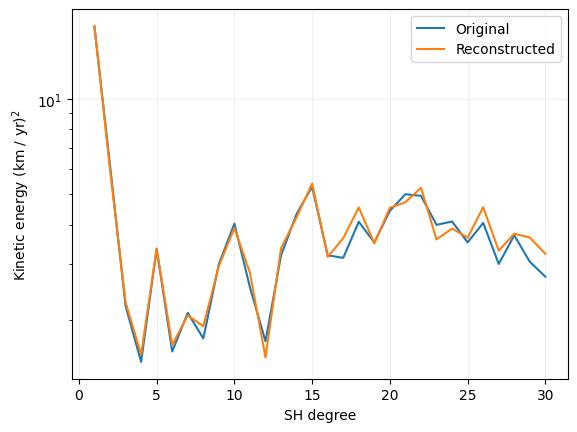

In [9]:
S = numpy.zeros((l_trunc + 1))
S_reconstructed = numpy.zeros((l_trunc + 1))

for l in range(1, l_trunc + 1):
    for m in range(0, l + 1):
        S[l] += (l*(l+1) / (2*l+1)) * (coeffs_t_cos[l, m]**2 + coeffs_t_sin[l, m]**2 + coeffs_s_cos[l, m]**2 + coeffs_s_sin[l, m]**2)
        S_reconstructed[l] += (l*(l+1) / (2*l+1)) * (coeffs_t_cos_2[l, m]**2 + coeffs_t_sin_2[l, m]**2 + coeffs_s_cos_2[l, m]**2 + coeffs_s_sin_2[l, m]**2)

l = numpy.arange(0, l_trunc + 1, 1)

plt.plot(l[1:], S[1:], label="Original")
plt.plot(l[1:], S_reconstructed[1:], label="Reconstructed")

plt.yscale("log")
plt.legend()

plt.grid(alpha=0.2)

plt.xlabel("SH degree")
plt.ylabel("Kinetic energy (km / yr)$^2$")